In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from src.rv_estimators import close_to_close_rv, parkinson_rv, garman_klass_rv, yang_zhang_rv

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

def find_project_root(marker=".gitignore"):
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find {marker} in any parent directory")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"

sp = pd.read_parquet(DATA_DIR / "spy_prices.parquet")
vh = pd.read_parquet(DATA_DIR / "spy_volatility_history.parquet")

rv_21 = close_to_close_rv(sp["Close"], window=21)
park_rv_21 = parkinson_rv(sp['High'], sp['Low'], window=21)
klass_rv_21 = garman_klass_rv(sp['High'], sp['Low'], sp['Open'], sp['Close'], window=21)
yang_zhang_rv_21 = yang_zhang_rv(sp['High'], sp['Low'], sp['Open'], sp['Close'], window=21)

In [21]:
vix = pd.read_parquet(DATA_DIR / "vix_prices.parquet")
vix.index.name = 'date'

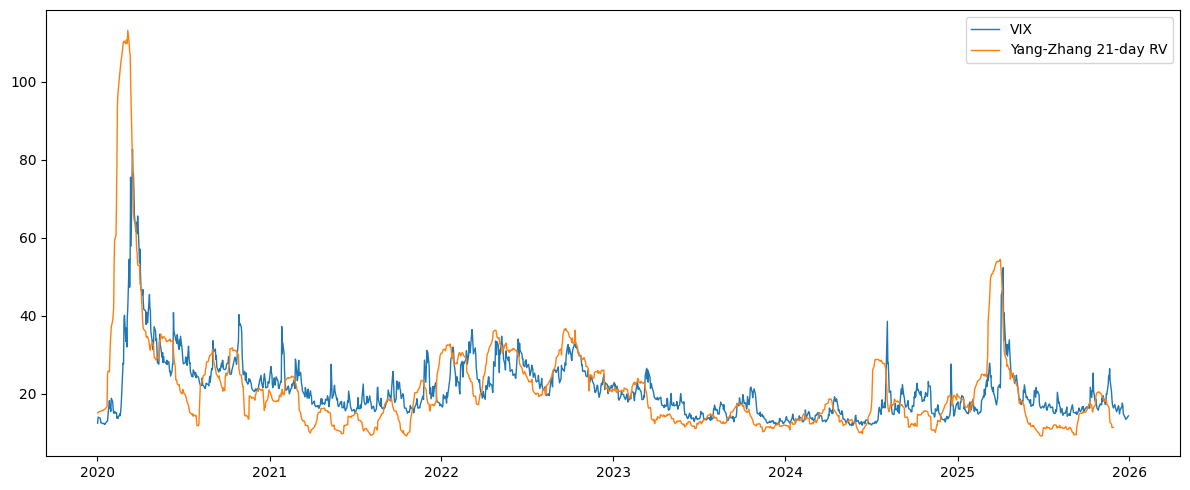

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(vix.index, vix['Close'], linewidth=1, label='VIX')
ax.plot(yang_zhang_rv_21.index, yang_zhang_rv_21.shift(-21) * 100 * np.sqrt(365 / 252), linewidth=1, label="Yang-Zhang 21-day RV")
plt.legend()
plt.tight_layout()
plt.show()

Mean VRP: 3.36
Median VRP: 4.20
Mean VRP excl. 2020: 3.89
Median VRP excl. 2020: 4.05
Mean VRP excl. shocks: 4.59
Median VRP excl. shocks: 4.32


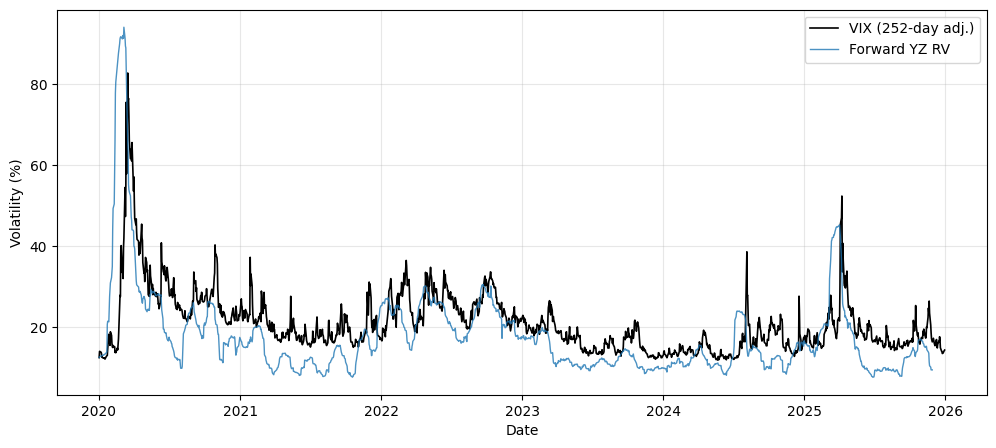

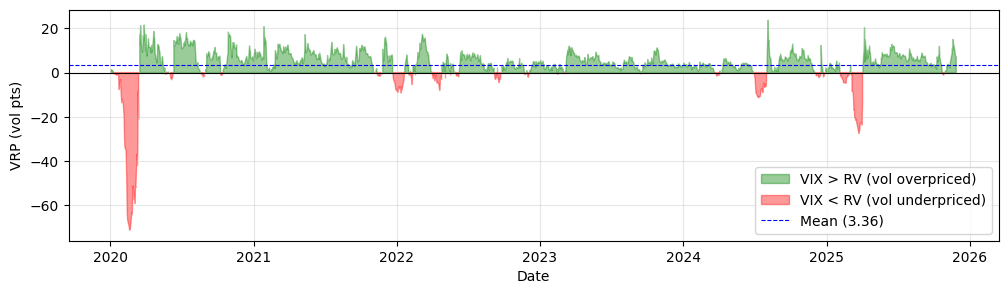

In [27]:
vix_adjusted = vix["Close"]

vrp = (vix_adjusted - yang_zhang_rv_21.shift(-21) * 100).dropna()

print(f"Mean VRP: {vrp.mean():.2f}")
print(f"Median VRP: {vrp.median():.2f}")
print(f"Mean VRP excl. 2020: {vrp.loc['2021':].mean():.2f}")
print(f"Median VRP excl. 2020: {vrp.loc['2021':].median():.2f}")
print(f"Mean VRP excl. shocks: {vrp[vrp > -20].mean():.2f}")
print(f"Median VRP excl. shocks: {vrp[vrp > -20].median():.2f}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(vix_adjusted.index, vix_adjusted, linewidth=1.2, label="VIX (252-day adj.)", color="black")
ax.plot(yang_zhang_rv_21.index, yang_zhang_rv_21.shift(-21) * 100, linewidth=1, alpha=0.8, label=f"Forward YZ RV")
ax.set_xlabel("Date")
ax.set_ylabel("Volatility (%)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show(fig)

fig2, ax2 = plt.subplots(figsize=(12, 3))
ax2.fill_between(vrp.index, vrp, 0, where=(vrp >= 0), alpha=0.4, color="green", label="VIX > RV (vol overpriced)")
ax2.fill_between(vrp.index, vrp, 0, where=(vrp < 0), alpha=0.4, color="red", label="VIX < RV (vol underpriced)")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.axhline(vrp.mean(), color="blue", linewidth=0.8, linestyle="--", label=f"Mean ({vrp.mean():.2f})")
ax2.set_xlabel("Date")
ax2.set_ylabel("VRP (vol pts)")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="lower right")
plt.show(fig2)